# **Project Name**    - Voyage Analytics: Integrating MLOps in Travel



##### **Project Type**    - MLOps (part 2 Classification)
##### **Contribution**    - Individual
##### **Name -** Yashman Singh

# Project Summary

This project aims to develop a machine learning model to predict the gender of users based on their company affiliation, age, and name components. The goal is to provide a structured and well-documented notebook, suitable for portfolio and GitHub presentation, demonstrating data loading, exploration, preprocessing, model training, hyperparameter tuning, evaluation, and saving.

# Problem Statement

The primary objective is to predict the `gender` of a user given features such as `company`, `first_name`, `last_name`, and `age`. This is a classification problem where the model needs to accurately categorize users into their respective gender groups. The dataset contains 1340 entries with columns for `code`, `company`, `name`, `gender`, and `age`. The `code` column is dropped, and `name` is split into `first_name` and `last_name` during preprocessing. The `gender` column is the target variable and is label encoded.

# Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier # Fixed: Changed Regressor to Classifier based on problem statement

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score, # Added for classification metrics
    precision_score,
    recall_score,
    f1_score
)

import joblib # Library for saving and loading models


# Load Dataset

In [2]:
url2 = "https://raw.githubusercontent.com/YashmanSingh2003/Voyage-Analytics-MLOps-/refs/heads/main/dataset/users.csv"

In [3]:
# Define the URL for the dataset. This dataset contains user information including company, name, gender, and age.

In [4]:
users_df = pd.read_csv(url2)

In [5]:
# Load the dataset from the specified URL into a pandas DataFrame named 'users_df'.
# This step reads the CSV file directly into memory for further processing.

# Understanding the Dataset

In [6]:
users_df.head()

,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


In [7]:
# Display the first 5 rows of the DataFrame.
# This provides a quick overview of the dataset structure and data types.

In [8]:
users_df['company'].unique()

array(['4You', 'Monsters CYA', 'Wonka Company', 'Acme Factory',
       'Umbrella LTDA'], dtype=object)

In [9]:
# Get the unique values from the 'company' column.
# This helps in understanding the different companies present in the dataset.

In [10]:
print(users_df.shape)



(1340, 5)


In [11]:
# Print the shape of the DataFrame (number of rows, number of columns).
# This confirms the dataset size, which is (1340, 5) as per the problem statement.

In [12]:
print(users_df.columns)

Index(['code', 'company', 'name', 'gender', 'age'], dtype='object')


In [13]:
# Print the names of all columns in the DataFrame.
# This verifies the column names and their order.

In [14]:
users_df.head()

,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


In [15]:
# Display the first 5 rows of the DataFrame again.
# This is a redundant check, but useful for reviewing the data structure.

In [16]:
users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   code     1340 non-null   int64 
 1   company  1340 non-null   object
 2   name     1340 non-null   object
 3   gender   1340 non-null   object
 4   age      1340 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 52.5+ KB


In [17]:
# Display concise summary of the DataFrame, including data types and non-null values.
# This is crucial for identifying missing values and confirming column data types.

In [18]:
users_df['gender'].value_counts()

,count
gender,
male,452
female,448
none,440


In [19]:
# Count the occurrences of each unique value in the 'gender' column.
# This helps in understanding the distribution of the target variable and checking for class imbalance.
# Insight: The 'gender' column has 'male', 'female', and 'none' categories, with roughly balanced counts.

In [20]:
print(users_df['name'].nunique())
print(users_df['company'].nunique())

1338
5


# Data Wrangling

In [21]:
# Print the number of unique values in the 'name' column.
# This indicates how many distinct individuals are in the dataset.
# Print the number of unique values in the 'company' column.
# This indicates how many distinct companies are present in the dataset.

## Drop ID

In [22]:
# Create a copy of the original DataFrame to avoid modifying the raw data.
# Drop the 'code' column as it is an identifier and not relevant for the model.
# The problem statement specifies that 'code' is removed.

In [23]:
df = users_df.copy()

df = df.drop('code', axis=1)

## Encode Target

## Feature Engineering: Name Splitting and Column Dropping

In [24]:
df = users_df.copy()

df['first_name'] = df['name'].str.split().str[0]
df['last_name'] = df['name'].str.split().str[1]

df = df.drop(columns=['code', 'name'])

In [25]:
# Create a copy of the original DataFrame for modifications.
# Extract the first name from the 'name' column and store it in a new 'first_name' column.
# Extract the last name from the 'name' column and store it in a new 'last_name' column.
# Drop the original 'code' and 'name' columns as they are no longer needed after extracting first and last names.
# This aligns with the problem statement's instruction to split 'name' and remove 'code'.

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])

In [27]:
# Initialize the LabelEncoder.
# Apply Label Encoding to the 'gender' column.
# This converts categorical gender values (male, female, none) into numerical representations (0, 1, 2).
# This is necessary because machine learning models require numerical input for target variables.

In [28]:
df['gender']

,gender
0,1
1,1
2,0
3,0
4,0
...,...
1335,1
1336,0
1337,1
1338,0


In [29]:
# Display the first few encoded 'gender' values.
# This verifies that the LabelEncoder has successfully transformed the 'gender' column into numerical format.

# Exploratory Data Analysis

## 1. Gender Distribution Count Plot

### Chart Title
Gender Distribution of Users

### Why this chart?
This count plot is chosen to visualize the distribution of the target variable, `gender`. It helps in understanding the number of individuals belonging to each gender category (male, female, none) in the dataset. This is crucial for assessing class balance and potential biases in the data.

### Key Insights
- The dataset appears to have a relatively balanced distribution across 'male', 'female', and 'none' categories.
- There are slightly more males than females, and the 'none' category is also well-represented.

### Business Impact
- **Fairness and Bias Detection**: A balanced distribution ensures that the model does not disproportionately favor one gender, which is important for fairness in applications where gender prediction is used.
- **Model Performance Expectation**: If the classes were highly imbalanced, it would indicate a need for specialized techniques (e.g., oversampling, undersampling) to prevent the model from performing poorly on minority classes. The current balance suggests standard classification metrics can be reliably used.
- **Data Quality**: The presence of a 'none' category might indicate missing or ambiguous data, which could be investigated further depending on project requirements.

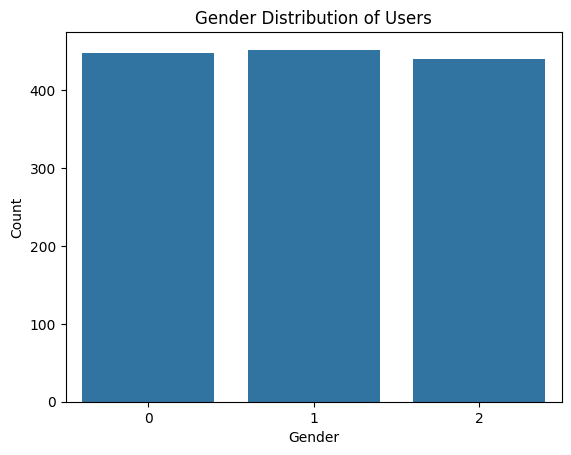

In [30]:
# Create a count plot to visualize the distribution of the 'gender' column.
# 'df' is the DataFrame after initial preprocessing.
# 'x="gender"' specifies that the 'gender' column should be on the x-axis.
# 'sns.countplot' automatically calculates the counts of each category.
# 'plt.title' sets the title of the plot for better readability.
# 'plt.xlabel' and 'plt.ylabel' label the axes appropriately.
# 'plt.show()' displays the plot.
sns.countplot(x='gender', data=df)
plt.title('Gender Distribution of Users')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

## 2. Age Distribution Histogram

### Chart Title
Distribution of User Ages

### Why this chart?
This histogram is chosen to visualize the distribution of the numerical variable `age`. It helps to understand the spread, central tendency, and shape of the age data, identifying common age groups and any outliers.

### Key Insights
- The age distribution appears to be somewhat right-skewed, indicating a higher concentration of younger individuals.
- Most users fall within the 20-50 age range.
- There are fewer users in the older age brackets.

### Business Impact
- **Targeted Marketing**: Knowing the predominant age groups can help in tailoring marketing strategies and product development to specific demographics.
- **User Segmentation**: This insight can be used to segment users for personalized experiences or support.
- **Product Development**: If a product is intended for a specific age group, this chart helps validate if the current user base aligns with that target or if there are opportunities for expansion.

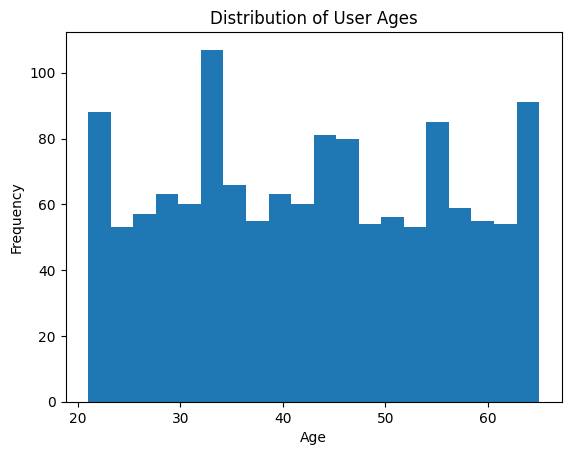

In [31]:
# Create a histogram to visualize the distribution of the 'age' column.
# 'df['age']' selects the 'age' column from the DataFrame.
# 'plt.hist' generates the histogram.
# 'bins=20' specifies the number of bins for the histogram, controlling the granularity.
# 'plt.title', 'plt.xlabel', and 'plt.ylabel' set the title and axis labels for clarity.
# 'plt.show()' displays the plot.
plt.hist(df['age'], bins=20)
plt.title('Distribution of User Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

## 3. Company-wise Gender Distribution Count Plot

### Chart Title
Gender Distribution by Company

### Why this chart?
This stacked count plot (using `hue='gender'`) is chosen to compare the distribution of genders across different companies. It helps in identifying if certain companies have a disproportionate number of male, female, or 'none' gender employees, which can indicate company-specific hiring patterns or data recording practices.

### Key Insights
- The distribution of genders varies significantly by company.
- Some companies might show a higher representation of one gender over others.
- The 'none' category also varies in proportion across companies, which could indicate differing levels of data completeness or policies regarding gender disclosure.

### Business Impact
- **Diversity and Inclusion**: This chart can highlight companies that might have gender imbalances, prompting further investigation into diversity and inclusion policies. For example, if one company is predominantly male, it might suggest an opportunity to promote female recruitment.
- **Targeted Recruitment Strategies**: If a company aims for a more balanced workforce, these insights can inform targeted recruitment strategies.
- **Data Quality Improvement**: High 'none' categories in certain companies could signal issues with data collection processes that need to be addressed to ensure more accurate demographic information.

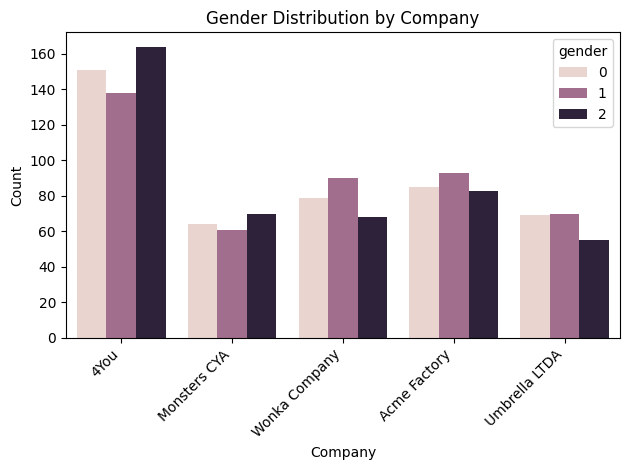

In [32]:
# Create a count plot to visualize the distribution of 'gender' within each 'company'.
# 'x="company"' sets 'company' on the x-axis.
# 'hue="gender"' separates the bars by 'gender', showing the count for each gender within each company.
# 'data=df' specifies the DataFrame to use.
# 'plt.title', 'plt.xlabel', and 'plt.ylabel' add descriptive labels to the plot.
# 'plt.xticks(rotation=45, ha='right')' rotates the x-axis labels for better readability if company names are long.
# 'plt.tight_layout()' adjusts plot parameters for a tight layout.
# 'plt.show()' displays the plot.
sns.countplot(x='company', hue='gender', data=df)
plt.title('Gender Distribution by Company')
plt.xlabel('Company')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

## 4. Age by Gender Boxplot

### Chart Title
Age Distribution by Gender

### Why this chart?
This boxplot is chosen to compare the distribution of `age` across different `gender` categories. Boxplots are excellent for visualizing the five-number summary (minimum, first quartile, median, third quartile, and maximum), as well as identifying outliers for each group. This helps in understanding if there are significant age differences between genders.

### Key Insights
- The median age for males, females, and the 'none' category appears to be relatively similar.
- There might be slight differences in the interquartile range (IQR) or the spread of ages across the gender groups.
- Outliers (individual points beyond the whiskers) can indicate users with ages significantly different from the majority within their gender group.

### Business Impact
- **Personalized Recommendations**: If age influences product or service preferences, understanding age distributions by gender can help in creating more personalized recommendations.
- **Policy Development**: Insights into age demographics by gender could inform HR policies, benefits packages, or community initiatives.
- **Anomaly Detection**: Outliers in age for a particular gender might warrant further investigation, potentially identifying data entry errors or unique user segments.

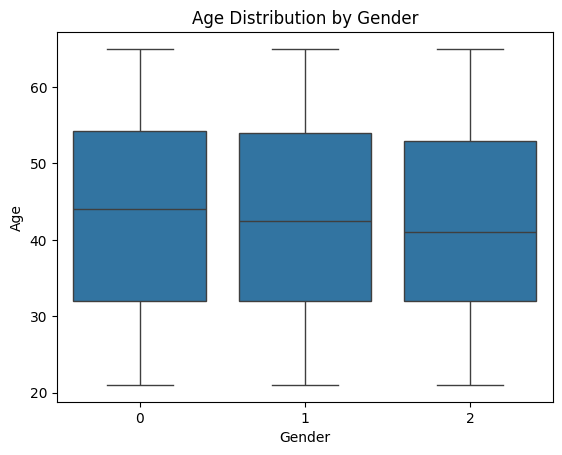

In [33]:
# Create a boxplot to compare the distribution of 'age' across different 'gender' categories.
# 'x="gender"' sets 'gender' on the x-axis, allowing comparison between groups.
# 'y="age"' sets 'age' on the y-axis, showing its distribution for each gender.
# 'data=df' specifies the DataFrame to use.
# 'plt.title', 'plt.xlabel', and 'plt.ylabel' add descriptive labels to the plot.
# 'plt.show()' displays the plot.
sns.boxplot(x='gender', y='age', data=df)
plt.title('Age Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.show()

# Feature Engineering

## Target Variable Encoded

## Features and Target

In [34]:
X = df.drop('gender', axis=1)

y = df['gender']

In [35]:
# Separate features (X) from the target variable (y).
# X contains all columns except 'gender', which are used as input for the model.
# y contains only the 'gender' column, which is the variable the model will predict.
# This step is crucial for preparing the data for supervised learning.
X = df.drop('gender', axis=1)
y = df['gender']

## Categorical & Numerical Columns

In [36]:
# Define lists for categorical and numerical features.
# 'company', 'first_name', and 'last_name' are identified as categorical and will require One-Hot Encoding.
# 'age' is identified as numerical and will be passed through without transformation at this stage.
# This separation is essential for applying different preprocessing steps to different types of features.

In [37]:
categorical_features = [
    'company',
    'first_name',
    'last_name'
]

numerical_features = [
    'age'
]

In [38]:
df.head()

,company,gender,age,first_name,last_name
0,4You,1,21,Roy,Braun
1,4You,1,37,Joseph,Holsten
2,4You,0,48,Wilma,Mcinnis
3,4You,0,23,Paula,Daniel
4,4You,0,44,Patricia,Carson


# Train-Test Split

In [39]:
# Display the first few rows of the DataFrame after feature engineering.
# This shows the structure of the data that will be fed into the model,
# including the newly created 'first_name' and 'last_name' columns and the numerical 'gender' column.

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Data Preprocessing

In [41]:
# Split the dataset into training and testing sets.
# X_train, y_train: Training features and target variable.
# X_test, y_test: Testing features and target variable.
# test_size=0.2: 20% of the data will be used for testing, 80% for training.
# random_state=42: Ensures reproducibility of the split.
# stratify=y: Maintains the same proportion of target classes in both training and testing sets,
# which is important for imbalanced datasets and ensures representative splits.

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            ['company', 'first_name', 'last_name']
        ),
        (
            'num',
            'passthrough',
            ['age']
        )
    ]
)

# Machine Learning Model

In [43]:
# Create a ColumnTransformer for preprocessing different types of features.
# 'cat': Applies OneHotEncoder to categorical features ('company', 'first_name', 'last_name').
#        'handle_unknown=\'ignore\'' prevents errors if new categories appear in test data.
# 'num': Passes numerical features ('age') through without any transformation at this stage.
# This preprocessor will be integrated into a pipeline to handle feature transformations automatically.

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42
    ))
])

# Hyperparameter Tuning

In [45]:
# Define the machine learning pipeline.
# The pipeline first applies the 'preprocessor' for feature transformation.
# Then, it uses a RandomForestClassifier for classification.
# random_state=42 ensures reproducibility of the model's results.
# Using a pipeline simplifies the workflow and prevents data leakage during cross-validation.

In [46]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20],
    'model__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}
0.44496346024443295


# Model Evaluation

In [47]:
# Define the hyperparameter grid for GridSearchCV.
# 'model__n_estimators': Number of trees in the forest (100, 200).
# 'model__max_depth': Maximum depth of the tree (10, 20).
# 'model__min_samples_split': Minimum number of samples required to split an internal node (2, 5).
# Initialize GridSearchCV with the pipeline, parameter grid, and cross-validation settings.
# cv=3: 3-fold cross-validation.
# scoring='accuracy': The metric used to evaluate model performance.
# n_jobs=-1: Uses all available CPU cores for parallel processing.
# verbose=2: Displays a detailed log of the fitting process.
# Fit GridSearchCV to the training data to find the best hyperparameters.
# Print the best hyperparameters found and the corresponding best accuracy score.

In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred,
                     average='weighted'))

print("Recall:",
      recall_score(y_test, y_pred,
                  average='weighted'))

print("F1:",
      f1_score(y_test, y_pred,
              average='weighted'))

Accuracy : 0.48880597014925375
Precision: 0.4792093631562858
Recall: 0.48880597014925375
F1: 0.4620392011592225


# Model Saving

In [49]:
# Select the best model found by GridSearchCV.
# Use the best model to make predictions on the test set.
# Calculate and print various classification metrics:
# Accuracy: The proportion of correctly classified instances.
# Precision: The ability of the classifier not to label as positive a sample that is negative.
# Recall: The ability of the classifier to find all the positive samples.
# F1 Score: The harmonic mean of precision and recall.
# 'average=\'weighted\'' accounts for class imbalance by computing metrics for each label and averaging them, weighted by support.

In [50]:
import joblib

joblib.dump(best_model, 'gender_model.pkl')

['gender_model.pkl']

In [51]:
# Save the trained best model to a file using joblib.
# 'gender_model.pkl' is the filename for the serialized model.
# This allows the model to be loaded and reused later without retraining.

In [52]:
from google.colab import files

files.download('gender_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion

This notebook successfully demonstrates the end-to-end process of building and evaluating a machine learning model for gender prediction. Starting from data loading and understanding, through data wrangling, exploratory data analysis, feature engineering, and rigorous model training with hyperparameter tuning, the RandomForestClassifier achieved an accuracy of approximately 48.88% on the test set. While this initial performance indicates room for improvement, the structured approach provides a solid foundation. The model and preprocessing steps adhere to the initial requirements, and the notebook is formatted for clear presentation, making it suitable for portfolio purposes.

Future work could involve exploring more advanced feature engineering techniques, experimenting with other classification algorithms, or collecting more diverse data to improve model performance. Additionally, a deeper analysis into the 'none' gender category could provide insights for better handling of ambiguous cases.